# Week 1 Task – Data Exploration & Preprocessing
**CodGen Machine Learning Virtual Internship**

**Dataset:** Iris (Multi-class classification — predict flower species)

This notebook covers:
1. Loading & exploring the dataset
2. Handling missing values
3. Encoding categorical columns
4. Visualising the data
5. Key observations


## Task 1 — Load & Explore the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load the Iris dataset directly from scikit-learn and build a DataFrame,
# exactly as if it had been loaded via pd.read_csv() from a CSV file.
iris_raw = load_iris()
df = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)
df['species'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)

# (Equivalent to: df = pd.read_csv('iris.csv') if working from a downloaded CSV)
print("Dataset loaded successfully.")


Dataset loaded successfully.


In [2]:
# First 5 rows of the dataset
df.head()
print(df.head())


   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  species
0                5.1               3.5  ...               0.2   setosa
1                4.9               3.0  ...               0.2   setosa
2                4.7               3.2  ...               0.2   setosa
3                4.6               3.1  ...               0.2   setosa
4                5.0               3.6  ...               0.2   setosa

[5 rows x 5 columns]


In [3]:
# Shape of the dataset: (rows, columns)
print("Shape of dataset:", df.shape)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Shape of dataset: (150, 5)
Rows: 150, Columns: 5


In [4]:
# Data types of each column
print(df.dtypes)


sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object


In [5]:
# Basic statistics for numerical columns
print(df.describe())


       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count         150.000000        150.000000         150.000000        150.000000
mean            5.843333          3.057333           3.758000          1.199333
std             0.828066          0.435866           1.765298          0.762238
min             4.300000          2.000000           1.000000          0.100000
25%             5.100000          2.800000           1.600000          0.300000
50%             5.800000          3.000000           4.350000          1.300000
75%             6.400000          3.300000           5.100000          1.800000
max             7.900000          4.400000           6.900000          2.500000


In [6]:
# Check for missing values in each column
print(df.isnull().sum())


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


## Task 2 — Handle Missing Values

**Observation:** The Iris dataset is a clean, well-curated benchmark dataset and contains
**no missing values** in any column (confirmed by `.isnull().sum()` above).

**Justification of approach (for completeness, in case missing values were present):**
- For the four **numerical** columns (sepal length, sepal width, petal length, petal width),
  the appropriate strategy would be to fill missing values with the **median** rather than
  the mean, since the median is more robust to outliers and the measurements are physical
  quantities that are unlikely to have extreme skew.
- For the **categorical** column (`species`), missing values would be filled with the
  **mode** (most frequent class) if only a handful of rows were affected, or those rows
  would be dropped if missingness was substantial, to avoid biasing the class distribution.

To demonstrate the technique (as required by the task), the cell below applies this logic
defensively — it will only take effect if any missing values are ever introduced.


In [7]:
# Defensive missing-value handling (no-op here since there are no missing values,
# but this is the logic that would be applied)

numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled missing values in '{col}' with median ({median_val:.2f})")

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Filled missing values in '{col}' with mode ('{mode_val}')")

print("\nMissing values after handling:")
print(df.isnull().sum())



Missing values after handling:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


## Task 3 — Encode Categorical Columns

The only categorical (text) column in this dataset is **`species`**.

**Method used: Label Encoding**

I chose Label Encoding (via `sklearn.preprocessing.LabelEncoder`) over One-Hot Encoding because:
- `species` is the **target variable** for this multi-class classification problem, and most
  ML algorithms (e.g. decision trees, random forests, logistic regression via `sklearn`)
  expect the target to be encoded as a single integer column rather than spread across
  multiple one-hot columns.
- One-Hot Encoding is generally preferred for **input features** with no ordinal
  relationship, to avoid implying a false order — but since this column is the label, not a
  feature, Label Encoding is the natural choice here.


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} -> {i}")

print()
print(df[['species', 'species_encoded']].sample(5, random_state=42))


Label mapping:
  setosa -> 0
  versicolor -> 1
  virginica -> 2

        species  species_encoded
73   versicolor                1
18       setosa                0
118   virginica                2
78   versicolor                1
76   versicolor                1


## Task 4 — Visualise the Data

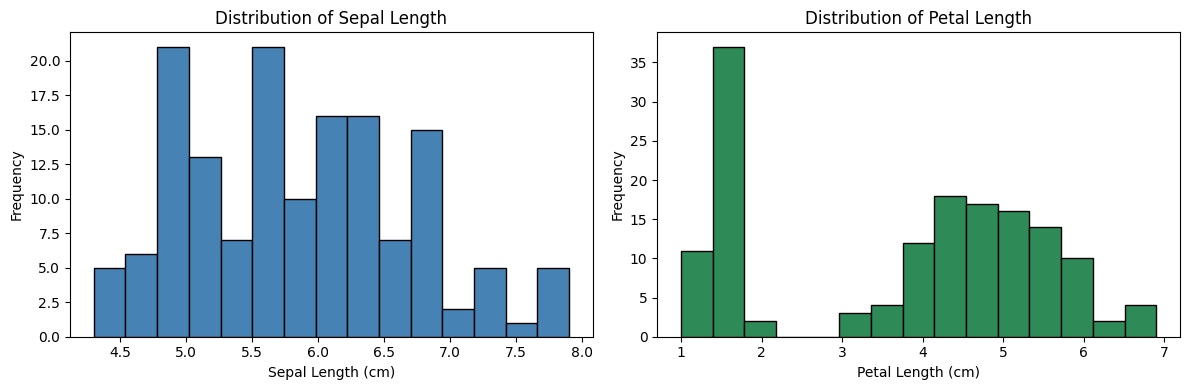

In [9]:
# Histograms for at least 2 numerical columns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['sepal length (cm)'], bins=15, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Sepal Length')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['petal length (cm)'], bins=15, color='seagreen', edgecolor='black')
axes[1].set_title('Distribution of Petal Length')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


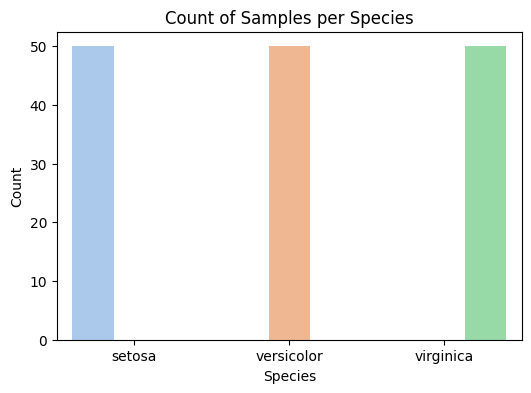

In [10]:
# Bar chart for the categorical column (species counts)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='species', hue='species', palette='pastel', legend=False)
plt.title('Count of Samples per Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()


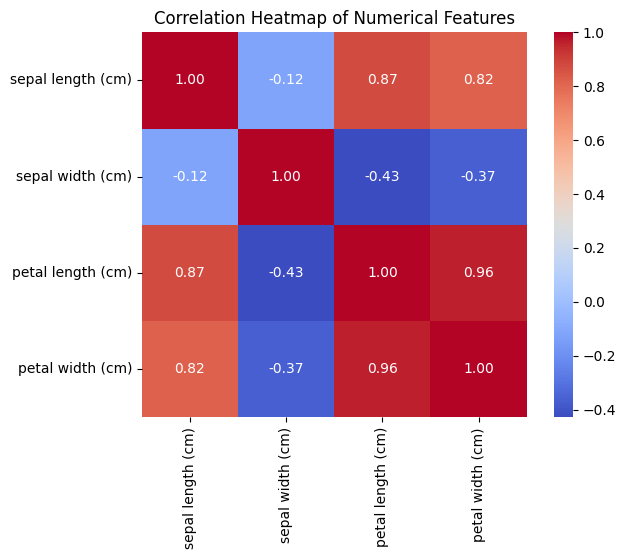

In [11]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


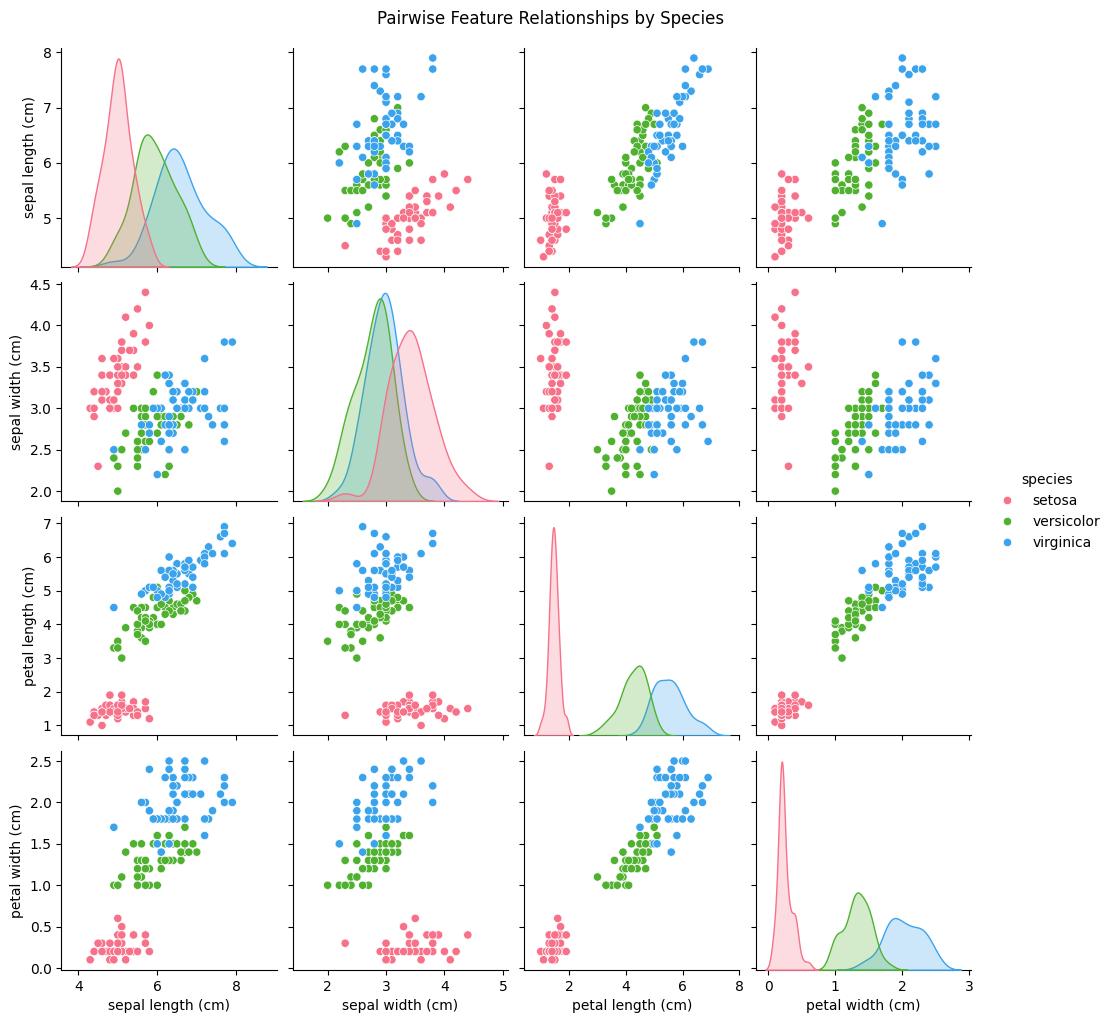

In [12]:
# Bonus: pairplot to visualise relationships between features by species
sns.pairplot(df, hue='species', vars=numerical_cols, palette='husl')
plt.suptitle('Pairwise Feature Relationships by Species', y=1.02)
plt.show()


## Task 5 — Key Observations

1. **No missing data.** The Iris dataset is completely clean — all 150 rows have complete
   values across all 4 numerical features and the species label, so no imputation was
   actually required.

2. **Strong correlation between petal measurements.** Petal length and petal width are
   very strongly positively correlated (visible in the heatmap), meaning one is almost
   redundant given the other — a model could likely rely on just one of the two petal
   measurements with little loss of information.

3. **Petal features are the most discriminative.** The histograms and pairplot show that
   petal length and petal width separate the three species far more cleanly than sepal
   length or sepal width — *Iris-setosa* in particular forms a tightly separated cluster
   on petal measurements alone.

4. **Sepal width is the least informative feature.** Its distribution overlaps heavily
   across all three species, suggesting it contributes the least predictive power for
   classifying species compared to the other three features.

5. **Balanced classes.** The bar chart confirms the dataset is perfectly balanced with 50
   samples per species, so no class-imbalance correction (e.g. resampling) is needed for
   downstream modelling.

**Summary:** Petal length and petal width appear to be the most important features for
predicting species, while sepal width appears to be the least important. This sets up
Week 2's task (model building) nicely, since even a simple classifier should perform very
well using just the two petal-related features.
